# 📊 Firox-gym Churn Analysis — Full Analysis
**Author:** SONOU Finangnon Ronald Bienvenu

**Date:** 19-02-2025  

**Audience:** Data Analyst Professionnel Practical Exam

---

> **Business context:** Firox-gym is a subscription-based fitness app experiencing rising churn over the past two quarters. This notebook covers data validation, exploratory analysis, KPI definition and actionable recommendations.


## 0. Setup — Libraries & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────────────────────────────
BRAND_COLORS = {
    'primary':   '#2563EB',  # blue
    'danger':    '#DC2626',  # red  (churn)
    'success':   '#16A34A',  # green (retained)
    'neutral':   '#6B7280',  # grey
    'light':     '#F3F4F6',
}
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
})

print("Libraries loaded ✅")


Libraries loaded ✅


In [3]:
# ── Load raw data ────────────────────────────────────────────────────────────
ACC_PATH = 'da_firox_gym_account_info.csv'
SUP_PATH = 'da_firox_gym_customer_support.csv'
ACT_PATH = 'da_firox_gym_user_activity.csv'

acc_raw = pd.read_csv(ACC_PATH)
sup_raw = pd.read_csv(SUP_PATH)
act_raw = pd.read_csv(ACT_PATH)

print(f"account_info  : {acc_raw.shape}")
print(f"customer_support: {sup_raw.shape}")
print(f"user_activity : {act_raw.shape}")


account_info  : (400, 6)
customer_support: (918, 7)
user_activity : (445, 3)


---
## 1. Data Validation & Cleaning

Before any analysis we audit **every column** in every table for:
- Expected types, value ranges and allowed categories  
- Missing / null values  
- Format inconsistencies (IDs, dates, flags)  
- Logical coherence (e.g. price = 0 ↔ Free plan)

Decisions taken when the manager is unavailable are documented inline.


### 1.1 `account_info`

In [4]:
# ── Raw inspection ──────────────────────────────────────────────────────────
print("=== account_info raw ===")
display(acc_raw.head())

=== account_info raw ===


,customer_id,email,state,plan,plan_list_price,churn_status
0,C10000,user10000@example.com,New Jersey,Enterprise,105,Y
1,C10001,user10001@example.net,Louisiana,Basic,22,Y
2,C10002,user10002@example.net,Oklahoma,Basic,24,NaN
3,C10003,user10003@example.com,Michigan,Free,0,NaN
4,C10004,user10004@example.com,Texas,Enterprise,119,NaN


In [5]:
print("Checking missing values: ")
acc_raw.isnull().sum()

Checking missing values: 


customer_id          0
email                0
state                0
plan                 0
plan_list_price      0
churn_status       286
dtype: int64

In [6]:
# Checking for missing values and data types for account_info dataset
acc_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      400 non-null    object
 1   email            400 non-null    object
 2   state            400 non-null    object
 3   plan             400 non-null    object
 4   plan_list_price  400 non-null    int64 
 5   churn_status     114 non-null    object
dtypes: int64(1), object(5)
memory usage: 18.9+ KB


In [7]:
# ── Column-by-column validation ─────────────────────────────────────────────

acc = acc_raw.copy()

# customer_id: should be 'C' + numeric, unique, no nulls
assert acc['customer_id'].notna().all(), "customer_id has nulls!"
assert acc['customer_id'].is_unique, "customer_id is not unique!"
assert acc['customer_id'].str.match(r'^C\d+$').all(), "Unexpected customer_id format"
print("✅ customer_id: all present, unique, correct format")

# email: no nulls, basic format check
assert acc['email'].notna().all()
valid_email = acc['email'].str.contains(r'^[\w.]+@[\w.]+\.[a-z]{2,}$', regex=True)
print(f"✅ email: {valid_email.sum()}/{len(acc)} pass basic format check")

# state: US states, no nulls
assert acc['state'].notna().all()
print(f"✅ state: {acc['state'].nunique()} unique US states — no nulls")

# plan: categorical {Free, Basic, Pro, Enterprise}
expected_plans = {'Free', 'Basic', 'Pro', 'Enterprise'}
actual_plans = set(acc['plan'].unique())
assert actual_plans == expected_plans, f"Unexpected plans: {actual_plans - expected_plans}"
print(f"✅ plan: values = {sorted(actual_plans)} — as expected")

# plan_list_price: numeric, Free=0, others>0; some variation per plan is OK
price_issues = acc[(acc['plan'] == 'Free') & (acc['plan_list_price'] != 0)]
print(f"✅ plan_list_price: {len(price_issues)} Free users with price ≠ 0 (expected 0)")
print(acc.groupby('plan')['plan_list_price'].agg(['min','max','mean']).round(2))

# churn_status: 'Y' or NaN → encode as boolean
# DECISION: NaN = not churned (active subscribers). Column name differs from spec ('churn')
# but meaning is equivalent. We rename and encode.
print(f"\nchurn_status raw value counts (incl NaN):\n{acc['churn_status'].value_counts(dropna=False)}")
acc['churned'] = acc['churn_status'].eq('Y')  # NaN → False
acc.drop(columns=['churn_status'], inplace=True)
print(f"✅ churn encoded: {acc['churned'].sum()} churned | {(~acc['churned']).sum()} retained")

# Numeric user_id for join: strip 'C' prefix → integer
acc['user_id'] = acc['customer_id'].str.replace('C', '').astype(int)
acc.drop(columns=['customer_id','email'], inplace=True)

print("\n✅ account_info cleaning complete")
acc.head()


✅ customer_id: all present, unique, correct format
✅ email: 400/400 pass basic format check
✅ state: 50 unique US states — no nulls
✅ plan: values = ['Basic', 'Enterprise', 'Free', 'Pro'] — as expected
✅ plan_list_price: 0 Free users with price ≠ 0 (expected 0)
            min  max    mean
plan                        
Basic        10   30   19.87
Enterprise   81  148  116.01
Free          0    0    0.00
Pro          32   80   53.74

churn_status raw value counts (incl NaN):
churn_status
NaN    286
Y      114
Name: count, dtype: int64
✅ churn encoded: 114 churned | 286 retained

✅ account_info cleaning complete


,state,plan,plan_list_price,churned,user_id
0,New Jersey,Enterprise,105,True,10000
1,Louisiana,Basic,22,True,10001
2,Oklahoma,Basic,24,False,10002
3,Michigan,Free,0,False,10003
4,Texas,Enterprise,119,False,10004


In [8]:
acc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   state            400 non-null    object
 1   plan             400 non-null    object
 2   plan_list_price  400 non-null    int64 
 3   churned          400 non-null    bool  
 4   user_id          400 non-null    int64 
dtypes: bool(1), int64(2), object(2)
memory usage: 13.0+ KB


### 1.2 `customer_support`

In [9]:
print("=== customer_support raw ===")
display(sup_raw.head())
print("\nDtypes:\n", sup_raw.dtypes)
print("\nMissing values:\n", sup_raw.isnull().sum())
print("\nchannel unique:", sup_raw['channel'].unique())
print("topic unique:", sup_raw['topic'].unique())
print("state unique:", sup_raw['state'].unique())


=== customer_support raw ===


,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments
0,2025-06-13 05:55:17.154573,10125,chat,technical,11.48,1,NaN
1,2025-08-06 13:21:54.539551,10109,chat,account,1.01,0,NaN
2,2025-08-22 12:39:35.718663,10149,chat,technical,10.09,0,Erase my data from your systems.
3,2025-06-07 02:49:46.986055,10268,phone,account,9.10,1,NaN
4,2025-07-25 00:24:38.945079,10041,phone,other,2.28,1,NaN



Dtypes:
 ticket_time               object
user_id                    int64
channel                   object
topic                     object
resolution_time_hours    float64
state                      int64
comments                  object
dtype: object

Missing values:
 ticket_time                0
user_id                    0
channel                    0
topic                      0
resolution_time_hours      0
state                      0
comments                 872
dtype: int64

channel unique: ['chat' 'phone' '-' 'email']
topic unique: ['technical' 'account' 'other' 'billing']
state unique: [1 0]


In [10]:
sup_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_time            918 non-null    object 
 1   user_id                918 non-null    int64  
 2   channel                918 non-null    object 
 3   topic                  918 non-null    object 
 4   resolution_time_hours  918 non-null    float64
 5   state                  918 non-null    int64  
 6   comments               46 non-null     object 
dtypes: float64(1), int64(2), object(4)
memory usage: 50.3+ KB


In [11]:
sup = sup_raw.copy()

# ticket_time: parse datetime
sup['ticket_time'] = pd.to_datetime(sup['ticket_time'], errors='coerce')
null_dates = sup['ticket_time'].isna().sum()
print(f"✅ ticket_time parsed | {null_dates} failed to parse")

# user_id: integer, no nulls
assert sup['user_id'].notna().all()
print(f"✅ user_id: {sup['user_id'].nunique()} unique users in support data")

# channel: '-' is a bad value → replace with 'unknown'
# DECISION: '-' likely a data entry error or placeholder; replaced with 'unknown'
print(f"   channel before fix: {sup['channel'].value_counts().to_dict()}")
sup['channel'] = sup['channel'].replace('-', 'unknown')
print(f"✅ channel after fix:  {sup['channel'].value_counts().to_dict()}")

# topic: validate
expected_topics = {'technical', 'account', 'billing', 'other'}
assert set(sup['topic'].unique()) == expected_topics
print(f"✅ topic: {sorted(sup['topic'].unique())} — valid")

# resolution_time_hours: positive float
neg_res = (sup['resolution_time_hours'] < 0).sum()
print(f"✅ resolution_time_hours: min={sup['resolution_time_hours'].min():.2f}h | {neg_res} negative values")

# state: 0/1 binary (ticket resolved=1, open=0)
# DECISION: column named 'state' in support data — inferred as ticket resolution status
#           based on values 0/1 and context. We rename for clarity.
sup.rename(columns={'state': 'is_resolved'}, inplace=True)
print(f"✅ is_resolved (ticket state): {sup['is_resolved'].value_counts().to_dict()}")

# comments: free text, mostly null — no cleaning needed
print(f"   comments: {sup['comments'].isna().sum()} null (expected — optional field)")

# Drop comments (not used in analysis)
sup.drop(columns=['comments'], inplace=True)

print("\n✅ customer_support cleaning complete")
sup.head()

✅ ticket_time parsed | 0 failed to parse
✅ user_id: 367 unique users in support data
   channel before fix: {'email': 298, 'chat': 294, 'phone': 287, '-': 39}
✅ channel after fix:  {'email': 298, 'chat': 294, 'phone': 287, 'unknown': 39}
✅ topic: ['account', 'billing', 'other', 'technical'] — valid
✅ resolution_time_hours: min=0.52h | 0 negative values
✅ is_resolved (ticket state): {1: 504, 0: 414}
   comments: 872 null (expected — optional field)

✅ customer_support cleaning complete


,ticket_time,user_id,channel,topic,resolution_time_hours,is_resolved
0,2025-06-13 05:55:17.154573,10125,chat,technical,11.48,1
1,2025-08-06 13:21:54.539551,10109,chat,account,1.01,0
2,2025-08-22 12:39:35.718663,10149,chat,technical,10.09,0
3,2025-06-07 02:49:46.986055,10268,phone,account,9.10,1
4,2025-07-25 00:24:38.945079,10041,phone,other,2.28,1


In [12]:
sup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ticket_time            918 non-null    datetime64[ns]
 1   user_id                918 non-null    int64         
 2   channel                918 non-null    object        
 3   topic                  918 non-null    object        
 4   resolution_time_hours  918 non-null    float64       
 5   is_resolved            918 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 43.2+ KB


### 1.3 `user_activity`

In [13]:
print("=== user_activity raw ===")
display(act_raw.head())
print("\nDtypes:\n", act_raw.dtypes)
print("\nMissing values:\n", act_raw.isnull().sum())
print("\nevent_type unique:", act_raw['event_type'].unique())


=== user_activity raw ===


,event_time,user_id,event_type
0,2025-09-08 15:05:39.422721,10118,watch_video
1,2025-09-08 08:15:05.264103,10220,watch_video
2,2025-11-14 06:28:35.207671,10009,share_workout
3,2025-08-20 16:53:38.682901,10227,read_article
4,2025-07-24 16:47:31.728422,10123,track_workout



Dtypes:
 event_time    object
user_id        int64
event_type    object
dtype: object

Missing values:
 event_time    0
user_id       0
event_type    0
dtype: int64

event_type unique: ['watch_video' 'share_workout' 'read_article' 'track_workout']


In [14]:
act_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   event_time  445 non-null    object
 1   user_id     445 non-null    int64 
 2   event_type  445 non-null    object
dtypes: int64(1), object(2)
memory usage: 10.6+ KB


In [15]:
act = act_raw.copy()

# event_time: parse datetime
act['event_time'] = pd.to_datetime(act['event_time'], errors='coerce')
null_ev = act['event_time'].isna().sum()
print(f"✅ event_time parsed | {null_ev} failed to parse")

# user_id: no nulls
assert act['user_id'].notna().all()
print(f"✅ user_id: {act['user_id'].nunique()} unique active users")

# event_type: categorical
expected_events = {'watch_video', 'read_article', 'track_workout', 'share_workout'}
assert set(act['event_type'].unique()) == expected_events
print(f"✅ event_type: {sorted(act['event_type'].unique())} — valid")

print("\n✅ user_activity cleaning complete")
act.head()


✅ event_time parsed | 0 failed to parse
✅ user_id: 246 unique active users
✅ event_type: ['read_article', 'share_workout', 'track_workout', 'watch_video'] — valid

✅ user_activity cleaning complete


,event_time,user_id,event_type
0,2025-09-08 15:05:39.422721,10118,watch_video
1,2025-09-08 08:15:05.264103,10220,watch_video
2,2025-11-14 06:28:35.207671,10009,share_workout
3,2025-08-20 16:53:38.682901,10227,read_article
4,2025-07-24 16:47:31.728422,10123,track_workout


In [16]:
act.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   event_time  445 non-null    datetime64[ns]
 1   user_id     445 non-null    int64         
 2   event_type  445 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 10.6+ KB


---
## 2. Building the Analytical Dataset

We merge the three tables on `user_id`. Account info is the spine (400 users). Support and activity data are aggregated per user before joining.

**ID alignment note:** `account_info.customer_id` uses format `C10000`, while `customer_support.user_id` and `user_activity.user_id` use integer `10000`. We strip the prefix to align keys.


In [17]:
# ── Aggregate customer_support per user ──────────────────────────────────────
sup_agg = sup.groupby('user_id').agg(
    n_tickets        = ('ticket_time', 'count'),
    avg_resolution_h = ('resolution_time_hours', 'mean'),
    n_unresolved     = ('is_resolved', lambda x: (x == 0).sum()),
    n_billing        = ('topic', lambda x: (x == 'billing').sum()),
    n_technical      = ('topic', lambda x: (x == 'technical').sum()),
    n_account        = ('topic', lambda x: (x == 'account').sum()),
).reset_index()
sup_agg.head()

,user_id,n_tickets,avg_resolution_h,n_unresolved,n_billing,n_technical,n_account
0,10000,3,21.446667,1,1,0,1
1,10001,4,17.542500,1,2,1,0
2,10002,3,6.433333,1,0,1,0
3,10003,1,2.190000,0,0,0,0
4,10004,4,8.542500,2,2,2,0


In [18]:
# ── Aggregate user_activity per user ─────────────────────────────────────────
act_agg = act.groupby('user_id').agg(
    total_events     = ('event_type', 'count'),
    n_watch_video    = ('event_type', lambda x: (x == 'watch_video').sum()),
    n_track_workout  = ('event_type', lambda x: (x == 'track_workout').sum()),
    n_read_article   = ('event_type', lambda x: (x == 'read_article').sum()),
    n_share_workout  = ('event_type', lambda x: (x == 'share_workout').sum()),
    last_event       = ('event_time', 'max'),
    first_event      = ('event_time', 'min'),
).reset_index()
act_agg.head()

,user_id,total_events,n_watch_video,n_track_workout,n_read_article,n_share_workout,last_event,first_event
0,10000,3,1,0,2,0,2025-11-13 00:14:10.471225,2025-08-28 21:25:03.813835
1,10001,1,0,0,1,0,2025-06-22 06:40:26.706374,2025-06-22 06:40:26.706374
2,10002,1,0,0,1,0,2025-09-17 17:33:50.117062,2025-09-17 17:33:50.117062
3,10003,1,0,1,0,0,2025-09-15 10:21:59.595794,2025-09-15 10:21:59.595794
4,10004,4,3,1,0,0,2025-10-11 05:17:36.302142,2025-06-16 13:29:45.144880


In [19]:
# ── Master merge ─────────────────────────────────────────────────────────────
df = (acc
      .merge(sup_agg, on='user_id', how='left')
      .merge(act_agg, on='user_id', how='left'))
df.head()

,state,plan,plan_list_price,churned,user_id,n_tickets,avg_resolution_h,n_unresolved,n_billing,n_technical,n_account,total_events,n_watch_video,n_track_workout,n_read_article,n_share_workout,last_event,first_event
0,New Jersey,Enterprise,105,True,10000,3.0,21.446667,1.0,1.0,0.0,1.0,3.0,1.0,0.0,2.0,0.0,2025-11-13 00:14:10.471225,2025-08-28 21:25:03.813835
1,Louisiana,Basic,22,True,10001,4.0,17.542500,1.0,2.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,2025-06-22 06:40:26.706374,2025-06-22 06:40:26.706374
2,Oklahoma,Basic,24,False,10002,3.0,6.433333,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,2025-09-17 17:33:50.117062,2025-09-17 17:33:50.117062
3,Michigan,Free,0,False,10003,1.0,2.190000,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2025-09-15 10:21:59.595794,2025-09-15 10:21:59.595794
4,Texas,Enterprise,119,False,10004,4.0,8.542500,2.0,2.0,2.0,0.0,4.0,3.0,1.0,0.0,0.0,2025-10-11 05:17:36.302142,2025-06-16 13:29:45.144880


In [20]:
# Users with no activity or no ticket → fill with 0
numeric_fill = ['n_tickets','avg_resolution_h','n_unresolved','n_billing',
                'n_technical','n_account','total_events',
                'n_watch_video','n_track_workout','n_read_article','n_share_workout']
df[numeric_fill] = df[numeric_fill].fillna(0)

df['has_ticket']    = df['n_tickets'] > 0
df['has_activity']  = df['total_events'] > 0

print(f"Master dataset: {df.shape}")
print(f"Churned: {df['churned'].sum()} | Retained: {(~df['churned']).sum()}")
df.head(3)

Master dataset: (400, 20)
Churned: 114 | Retained: 286


,state,plan,plan_list_price,churned,user_id,n_tickets,avg_resolution_h,n_unresolved,n_billing,n_technical,n_account,total_events,n_watch_video,n_track_workout,n_read_article,n_share_workout,last_event,first_event,has_ticket,has_activity
0,New Jersey,Enterprise,105,True,10000,3.0,21.446667,1.0,1.0,0.0,1.0,3.0,1.0,0.0,2.0,0.0,2025-11-13 00:14:10.471225,2025-08-28 21:25:03.813835,True,True
1,Louisiana,Basic,22,True,10001,4.0,17.542500,1.0,2.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,2025-06-22 06:40:26.706374,2025-06-22 06:40:26.706374,True,True
2,Oklahoma,Basic,24,False,10002,3.0,6.433333,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,2025-09-17 17:33:50.117062,2025-09-17 17:33:50.117062,True,True


In [21]:
# ── Engagement level (created here so all downstream cells can use it) ────────
def engagement_bucket(n):
    if n == 0:    return 'Low'
    elif n <= 2:  return 'Medium'
    else:         return 'High'

df['engagement_level'] = df['total_events'].apply(engagement_bucket)
df['engagement_level'] = pd.Categorical(df['engagement_level'],
                                         categories=['Low', 'Medium', 'High'],
                                         ordered=True)
print("Engagement level distribution:")
print(df['engagement_level'].value_counts().sort_index())

Engagement level distribution:
engagement_level
Low       154
Medium    198
High       48
Name: count, dtype: int64


In [22]:
df.head()

,state,plan,plan_list_price,churned,user_id,n_tickets,avg_resolution_h,n_unresolved,n_billing,n_technical,...,total_events,n_watch_video,n_track_workout,n_read_article,n_share_workout,last_event,first_event,has_ticket,has_activity,engagement_level
0,New Jersey,Enterprise,105,True,10000,3.0,21.446667,1.0,1.0,0.0,...,3.0,1.0,0.0,2.0,0.0,2025-11-13 00:14:10.471225,2025-08-28 21:25:03.813835,True,True,High
1,Louisiana,Basic,22,True,10001,4.0,17.542500,1.0,2.0,1.0,...,1.0,0.0,0.0,1.0,0.0,2025-06-22 06:40:26.706374,2025-06-22 06:40:26.706374,True,True,Medium
2,Oklahoma,Basic,24,False,10002,3.0,6.433333,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,2025-09-17 17:33:50.117062,2025-09-17 17:33:50.117062,True,True,Medium
3,Michigan,Free,0,False,10003,1.0,2.190000,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,2025-09-15 10:21:59.595794,2025-09-15 10:21:59.595794,True,True,Medium
4,Texas,Enterprise,119,False,10004,4.0,8.542500,2.0,2.0,2.0,...,4.0,3.0,1.0,0.0,0.0,2025-10-11 05:17:36.302142,2025-06-16 13:29:45.144880,True,True,High


---
## 3. Exploratory Data Analysis

We explore churn patterns across three dimensions the business cares about:
1. **Plan type** — which tiers retain best?
2. **Engagement** — does activity predict churn?
3. **Customer support** — does contact frequency or topic signal churn?


### 3.1 Univariate — Churn Distribution by Plan (Bar Chart)

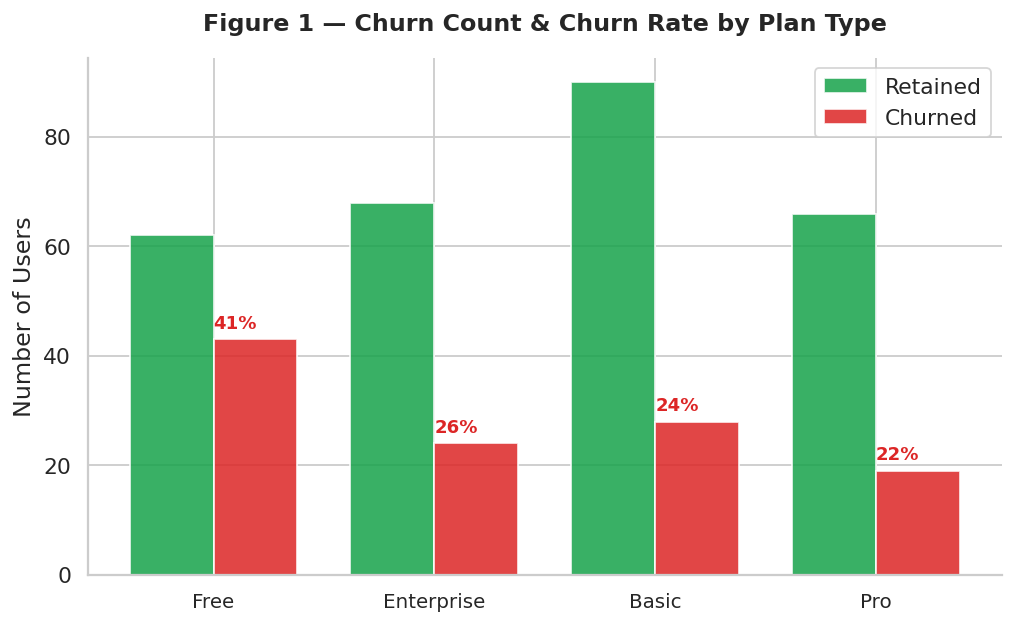


Churn rates by plan:
churned     Retained  Churned  Churn Rate
plan                                     
Free              62       43    0.409524
Enterprise        68       24    0.260870
Basic             90       28    0.237288
Pro               66       19    0.223529


In [23]:
# ── Graphic 1: Churn count by plan ──────────────────────────────────────────
plan_churn = (df.groupby(['plan', 'churned'])
               .size()
               .unstack(fill_value=0)
               .rename(columns={False: 'Retained', True: 'Churned'}))
plan_churn['Churn Rate'] = plan_churn['Churned'] / (plan_churn['Churned'] + plan_churn['Retained'])
plan_churn = plan_churn.sort_values('Churn Rate', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(plan_churn))
w = 0.38
bars_r = ax.bar(x - w/2, plan_churn['Retained'], w, label='Retained',color=BRAND_COLORS['success'], alpha=0.85)
bars_c = ax.bar(x + w/2, plan_churn['Churned'], w, label='Churned',color=BRAND_COLORS['danger'], alpha=0.85)

# Annotate churn rate
for i, (plan, row) in enumerate(plan_churn.iterrows()):
    ax.text(i, row['Churned'] + 2,f"{row['Churn Rate']:.0%}", ha='left', fontsize=10, fontweight='bold',color=BRAND_COLORS['danger'])

ax.set_xticks(x)
ax.set_xticklabels(plan_churn.index, fontsize=11)
ax.set_ylabel('Number of Users')
ax.set_title('Figure 1 — Churn Count & Churn Rate by Plan Type', fontweight='bold', pad=15)
ax.legend()
plt.tight_layout()
plt.savefig('fig1_churn_by_plan.png', bbox_inches='tight')
plt.show()

print("\nChurn rates by plan:")
print(plan_churn[['Retained','Churned','Churn Rate']].to_string())


### 3.2 Univariate — Distribution of Total App Events (Histogram)

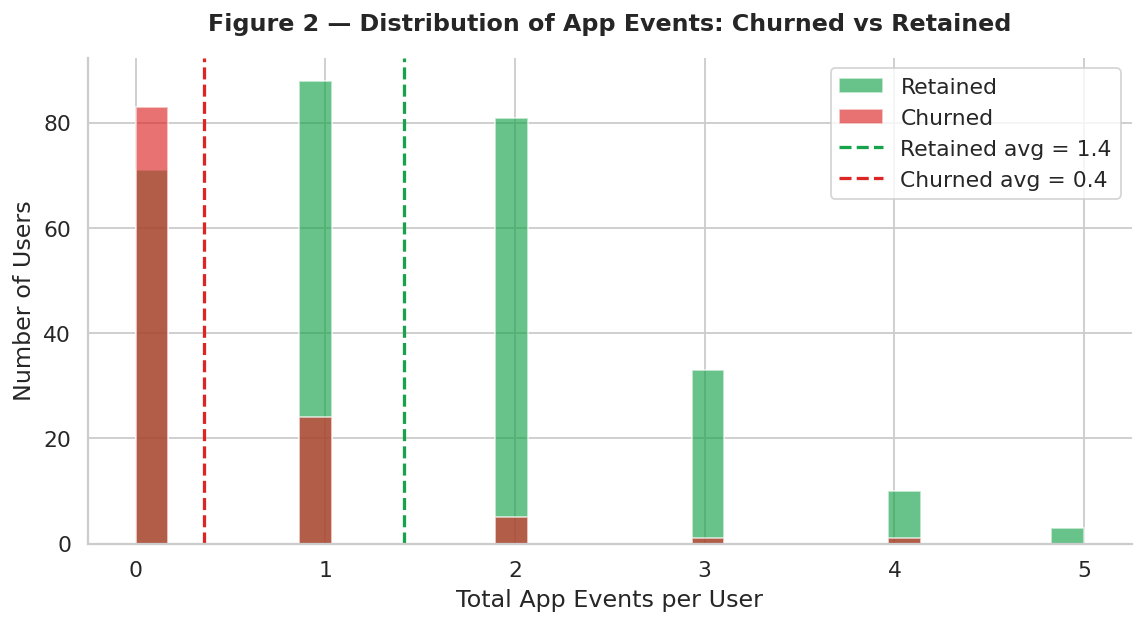

Mean events — Retained: 1.41 | Churned: 0.36
Median events — Retained: 1 | Churned: 0


In [24]:
# ── Graphic 2: Activity distribution — churned vs retained ──────────────────
fig, ax = plt.subplots(figsize=(9, 5))

churned_ev = df[df['churned']]['total_events']
retained_ev = df[~df['churned']]['total_events']

bins = np.linspace(0, df['total_events'].quantile(0.99) + 1, 30)

ax.hist(retained_ev, bins=bins, alpha=0.65, label='Retained',
        color=BRAND_COLORS['success'])
ax.hist(churned_ev,  bins=bins, alpha=0.65, label='Churned',
        color=BRAND_COLORS['danger'])

ax.axvline(retained_ev.mean(), color=BRAND_COLORS['success'], linestyle='--', linewidth=1.8,
           label=f'Retained avg = {retained_ev.mean():.1f}')
ax.axvline(churned_ev.mean(),  color=BRAND_COLORS['danger'],  linestyle='--', linewidth=1.8,
           label=f'Churned avg = {churned_ev.mean():.1f}')

ax.set_xlabel('Total App Events per User')
ax.set_ylabel('Number of Users')
ax.set_title('Figure 2 — Distribution of App Events: Churned vs Retained', fontweight='bold', pad=15)
ax.legend()
plt.tight_layout()
plt.savefig('fig2_activity_distribution.png', bbox_inches='tight')
plt.show()

print(f"Mean events — Retained: {retained_ev.mean():.2f} | Churned: {churned_ev.mean():.2f}")
print(f"Median events — Retained: {retained_ev.median():.0f} | Churned: {churned_ev.median():.0f}")


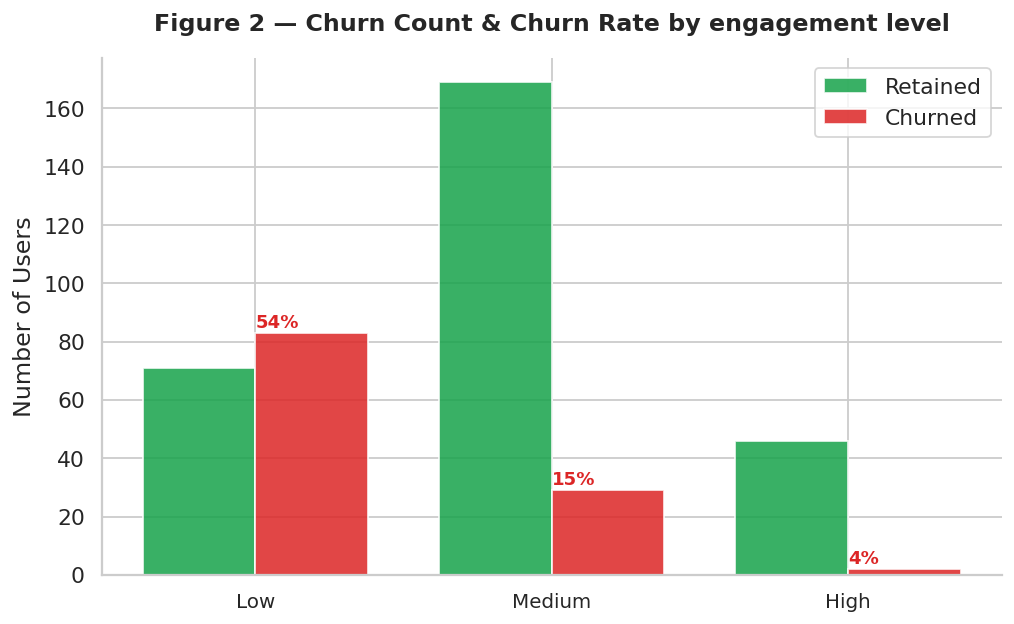


Churn rates by plan:
churned           Retained  Churned  Churn Rate
engagement_level                               
Low                     71       83    0.538961
Medium                 169       29    0.146465
High                    46        2    0.041667


In [25]:
# ── Graphic 2: Churn count by plan ──────────────────────────────────────────
eng_churn = (df.groupby(['engagement_level', 'churned'])
               .size()
               .unstack(fill_value=0)
               .rename(columns={False: 'Retained', True: 'Churned'}))
eng_churn['Churn Rate'] = eng_churn['Churned'] / (eng_churn['Churned'] + eng_churn['Retained'])
eng_churn = eng_churn.sort_values('Churn Rate', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(eng_churn))
w = 0.38
bars_r = ax.bar(x - w/2, eng_churn['Retained'], w, label='Retained',
                color=BRAND_COLORS['success'], alpha=0.85)
bars_c = ax.bar(x + w/2, eng_churn['Churned'], w, label='Churned',
                color=BRAND_COLORS['danger'], alpha=0.85)

# Annotate churn rate
for i, (eng, row) in enumerate(eng_churn.iterrows()):
    ax.text(i, row['Churned'] + 2,
            f"{row['Churn Rate']:.0%}", ha='left', fontsize=10, fontweight='bold',
            color=BRAND_COLORS['danger'])

ax.set_xticks(x)
ax.set_xticklabels(eng_churn.index, fontsize=11)
ax.set_ylabel('Number of Users')
ax.set_title('Figure 2 — Churn Count & Churn Rate by engagement level', fontweight='bold', pad=15)
ax.legend()
plt.tight_layout()
plt.savefig('fig2_churn_by_eng.png', bbox_inches='tight')
plt.show()

print("\nChurn rates by plan:")
print(eng_churn[['Retained','Churned','Churn Rate']].to_string())


### 3.3 Bivariate — Churn Rate by Plan × Engagement Level

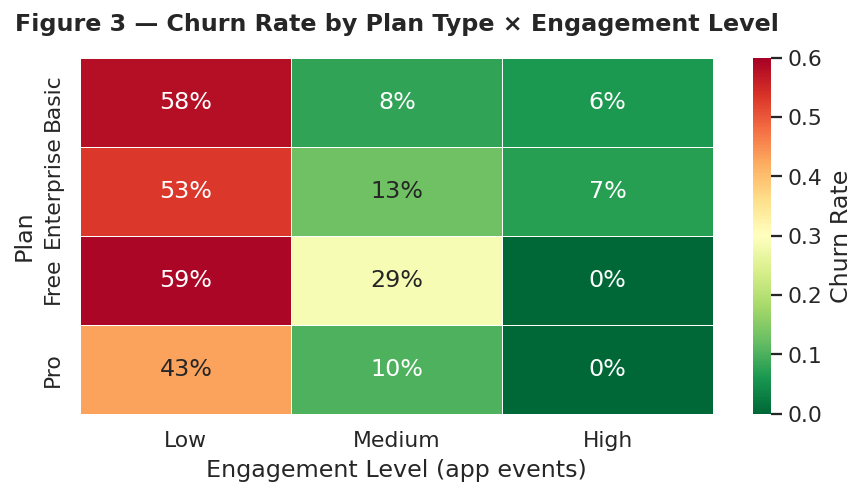

In [26]:
# ── Graphic 3: Heatmap — churn rate by plan & engagement bucket ─────────────
# (engagement_level created in Section 2 — merge cell)

heat_data = (df.groupby(['plan', 'engagement_level'])['churned']
               .mean()
               .unstack()
               .round(3))

# Ensure column order
heat_data = heat_data.reindex(columns=['Low', 'Medium', 'High'])

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(heat_data, annot=True, fmt='.0%', cmap='RdYlGn_r',
            vmin=0, vmax=0.6, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Churn Rate'})
ax.set_title('Figure 3 — Churn Rate by Plan Type × Engagement Level', fontweight='bold', pad=15)
ax.set_xlabel('Engagement Level (app events)')
ax.set_ylabel('Plan')
plt.tight_layout()
plt.savefig('fig3_heatmap_plan_engagement.png', bbox_inches='tight')
plt.show()


### 3.4 Bivariate — Support Ticket Volume vs Churn

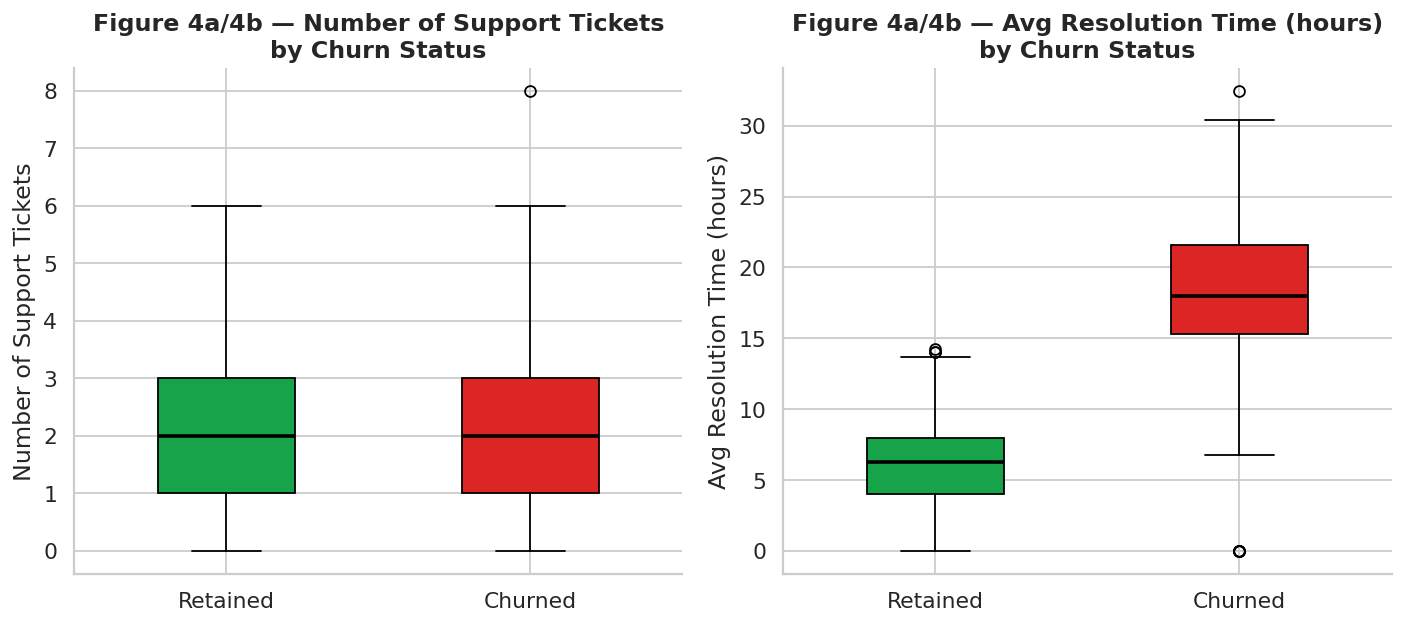

Support stats by churn group:
         n_tickets  avg_resolution_h  n_unresolved
churned                                           
False         2.23              6.01          1.01
True          2.45             17.87          1.11


In [27]:
# ── Graphic 4: Boxplot — ticket count distribution by churn status ────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Left: ticket count
for ax, col, label in zip(axes,['n_tickets', 'avg_resolution_h'],['Number of Support Tickets', 'Avg Resolution Time (hours)']):
    data = [df[~df['churned']][col].values, df[df['churned']][col].values]
    bp = ax.boxplot(data, patch_artist=True, widths=0.45,medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor(BRAND_COLORS['success'])
    bp['boxes'][1].set_facecolor(BRAND_COLORS['danger'])
    ax.set_xticklabels(['Retained', 'Churned'])
    ax.set_ylabel(label)
    ax.set_title(f'Figure 4a/4b — {label}\nby Churn Status', fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_support_boxplot.png', bbox_inches='tight')
plt.show()

print("Support stats by churn group:")
print(df.groupby('churned')[['n_tickets','avg_resolution_h','n_unresolved']].mean().round(2))


### 3.5 Bivariate — Churn Rate by Support Topic

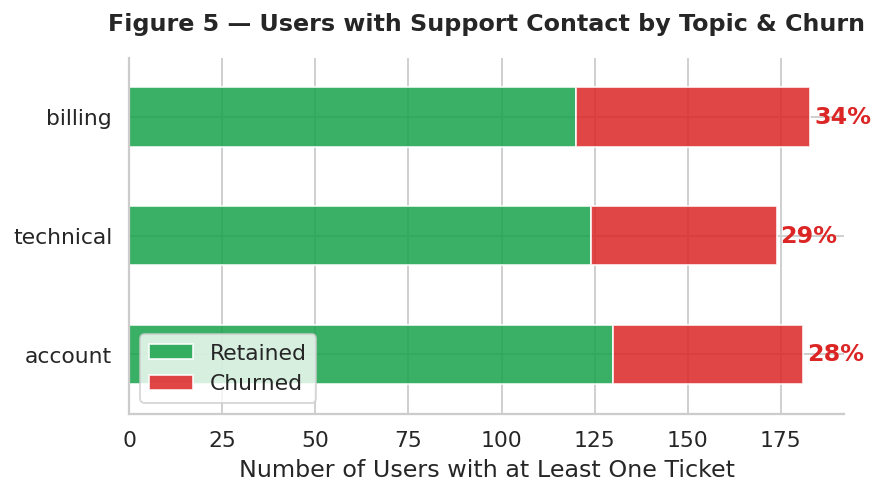

In [28]:
# ── Graphic 5: Stacked bar — topic exposure by churn ─────────────────────────
topic_churn = {}
for topic in ['n_billing', 'n_technical', 'n_account']:
    label = topic.replace('n_', '')
    topic_churn[label] = {
        'Retained': df[~df['churned'] & (df[topic] > 0)].shape[0],
        'Churned':  df[ df['churned'] & (df[topic] > 0)].shape[0],
    }

topic_df = pd.DataFrame(topic_churn).T
topic_df['total'] = topic_df['Retained'] + topic_df['Churned']
topic_df['churn_rate'] = topic_df['Churned'] / topic_df['total']
topic_df = topic_df.sort_values('churn_rate', ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
colors = [BRAND_COLORS['success'], BRAND_COLORS['danger']]
topic_df[['Retained', 'Churned']].plot(kind='barh', stacked=True, ax=ax,
                                        color=colors, alpha=0.85)
for i, (idx, row) in enumerate(topic_df.iterrows()):
    ax.text(row['total'] + 1, i, f"{row['churn_rate']:.0%}",
            va='center', fontweight='bold', color=BRAND_COLORS['danger'])

ax.set_xlabel('Number of Users with at Least One Ticket')
ax.set_title('Figure 5 — Users with Support Contact by Topic & Churn', fontweight='bold', pad=15)
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig('fig5_topic_churn.png', bbox_inches='tight')
plt.show()


### 3.6 Key Findings Summary

In [29]:
# ── Summary statistics table ─────────────────────────────────────────────────
summary = df.groupby('churned').agg(
    n_users           = ('user_id', 'count'),
    avg_events        = ('total_events', 'mean'),
    pct_no_activity   = ('has_activity', lambda x: (x == False).mean()),
    avg_tickets       = ('n_tickets', 'mean'),
    avg_resolution_h  = ('avg_resolution_h', 'mean'),
    pct_billing_issue = ('n_billing', lambda x: (x > 0).mean()),
).round(2)
summary.index = ['Retained', 'Churned']
display(summary)

print("\n🔑 Key findings:")
cr = df['churned'].mean()
print(f"  • Overall churn rate: {cr:.1%}")
print(f"  • Churned users had {summary.loc['Churned','avg_events']:.1f} avg events vs "
      f"{summary.loc['Retained','avg_events']:.1f} for retained")
print(f"  • {summary.loc['Churned','pct_no_activity']:.0%} of churned users had ZERO activity")
print(f"  • Churned users raised {summary.loc['Churned','avg_tickets']:.2f} avg tickets vs "
      f"{summary.loc['Retained','avg_tickets']:.2f} for retained")


,n_users,avg_events,pct_no_activity,avg_tickets,avg_resolution_h,pct_billing_issue
Retained,286,1.41,0.25,2.23,6.01,0.42
Churned,114,0.36,0.73,2.45,17.87,0.55



🔑 Key findings:
  • Overall churn rate: 28.5%
  • Churned users had 0.4 avg events vs 1.4 for retained
  • 73% of churned users had ZERO activity
  • Churned users raised 2.45 avg tickets vs 2.23 for retained


---
## 4. KPI Definition — Metric to Monitor

### Chosen Metric: Monthly Churn Rate (MCR)

**Definition:**  
$$\text{MCR} = \frac{\text{Number of subscribers who churned in month } M}{\text{Total active subscribers at start of month } M}$$

**Why this metric?**
- Directly measures the business problem (rising churn)
- Easy to track monthly without complex modelling
- Lagging indicator, but actionable: can be broken down by plan, cohort, or engagement tier

**Complementary leading indicators to monitor monthly:**
| Leading KPI | What it signals | Target direction |
|---|---|---|
| % Users with 0 events in last 30 days | Disengagement risk | ↓ Reduce |
| Avg resolution time (support tickets) | Support quality | ↓ Reduce |
| % Billing tickets per month | Payment friction | ↓ Reduce |
| % Users active ≥ 3 days/week | Core engagement | ↑ Increase |


In [30]:
# ── Monthly Churn Rate (MCR) — calculated from actual data ──────────────────
#
# METHODOLOGY:
#   • "first_seen" = earliest date a user appears in activity OR support data
#     → used as proxy for subscription start date
#   • "last_seen"  = latest date a user appears in activity OR support data
#   • For churned users: churn_month = month AFTER last_seen
#     (user was active in that month then disappeared)
#   • Active at start of month M = joined before M AND
#     (not churned OR churned during M or later)
#   • MCR(M) = churned_in_M / active_at_start_of_M
#   • Note: Jun 2025 excluded (partial month — first data point)

# Build enriched user table with temporal features
act_ts = act.groupby('user_id').agg(
    first_event=('event_time','min'),
    last_event=('event_time','max')).reset_index()
sup_ts = sup.groupby('user_id').agg(
    first_ticket=('ticket_time','min'),
    last_ticket=('ticket_time','max')).reset_index()

df_ts = acc[['user_id','churned']].merge(act_ts, on='user_id', how='left').merge(sup_ts, on='user_id', how='left')
df_ts['first_seen'] = df_ts[['first_event','first_ticket']].min(axis=1)
df_ts['last_seen']  = df_ts[['last_event','last_ticket']].max(axis=1)

df_ts['join_period'] = df_ts['first_seen'].dt.to_period('M')
df_ts['join_period'] = df_ts['join_period'].where(df_ts['join_period'].notna(), pd.Period('2025-06','M'))

def get_churn_period(row):
    if not row['churned']:
        return None
    if pd.isna(row['last_seen']):
        return pd.Period('2025-12','M')
    return (row['last_seen'] + pd.offsets.MonthBegin(1)).to_period('M')

df_ts['churn_period'] = df_ts.apply(get_churn_period, axis=1)

# Compute MCR month by month (Jul–Dec 2025)
months = pd.period_range('2025-07','2025-12', freq='M')
mcr_records = []
for m in months:
    active = df_ts[
        (df_ts['join_period'].notna()) &
        (df_ts['join_period'] < m) &
        (df_ts['churn_period'].isna() | (df_ts['churn_period'] >= m))
    ].shape[0]
    churned_m = df_ts[df_ts['churn_period'] == m].shape[0]
    mcr = churned_m / active * 100 if active > 0 else 0
    mcr_records.append({
        'Month': str(m),
        'Month_label': m.strftime('%b %Y'),
        'Active_Start': active,
        'Churned': churned_m,
        'MCR (%)': round(mcr, 2)
    })

mcr_df = pd.DataFrame(mcr_records)
avg_mcr = mcr_df['MCR (%)'].mean()
target_mcr = 5.0

print("=" * 55)
print("  MONTHLY CHURN RATE (MCR) — Jul to Dec 2025")
print("=" * 55)
print(mcr_df[['Month_label','Active_Start','Churned','MCR (%)']].to_string(index=False))
print(f"\n  Period average MCR : {avg_mcr:.2f}%")
print(f"  Peak MCR           : {mcr_df['MCR (%)'].max():.2f}% ({mcr_df.loc[mcr_df['MCR (%)'].idxmax(),'Month_label']})")
print(f"  Business target    : {target_mcr:.1f}%")
print(f"  Months above target: {(mcr_df['MCR (%)'] > target_mcr).sum()} / {len(mcr_df)}")

  MONTHLY CHURN RATE (MCR) — Jul to Dec 2025
Month_label  Active_Start  Churned  MCR (%)
   Jul 2025           161        5     3.11
   Aug 2025           259        8     3.09
   Sep 2025           328       13     3.96
   Oct 2025           348       22     6.32
   Nov 2025           343       36    10.50
   Dec 2025           316       28     8.86

  Period average MCR : 5.97%
  Peak MCR           : 10.50% (Nov 2025)
  Business target    : 5.0%
  Months above target: 3 / 6


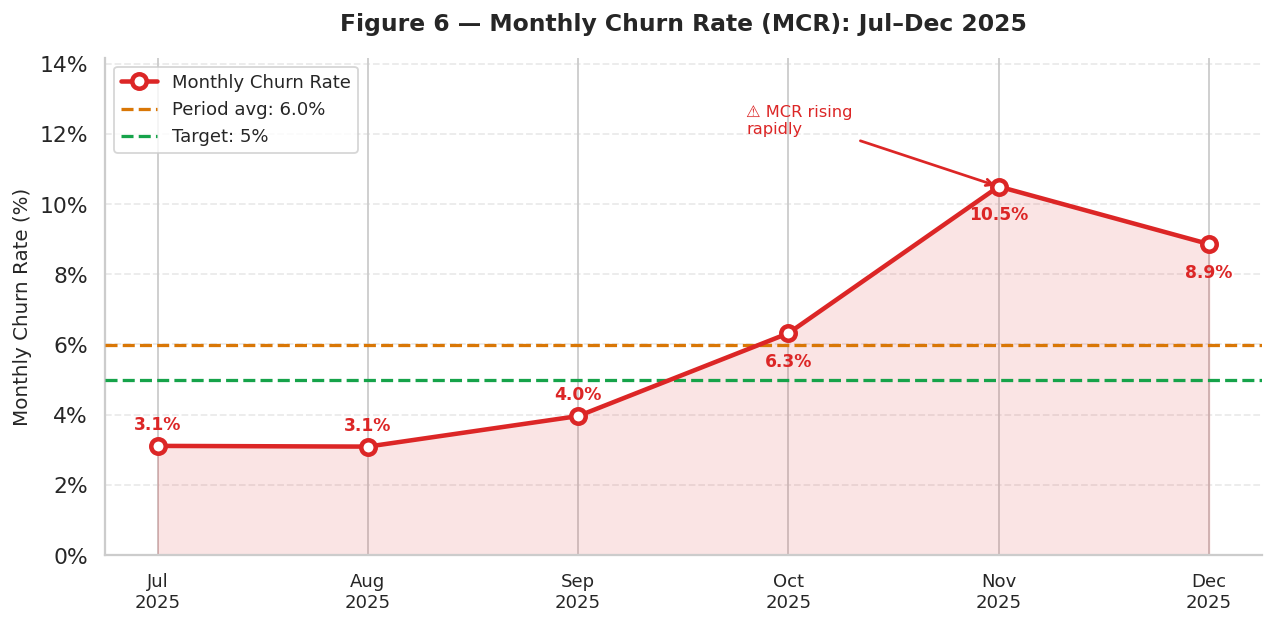

In [31]:
# ── Figure 7 & 8 — MCR trend + subscriber breakdown ─────────────────────────
import matplotlib.ticker as mtick

fig7, ax = plt.subplots(figsize=(10, 5))
fig7.patch.set_facecolor('white')
ax.set_facecolor('white')

x = np.arange(len(mcr_df))
month_labels = [m.strftime('%b\n%Y') for m in months]

ax.fill_between(x, mcr_df['MCR (%)'], alpha=0.12, color=BRAND_COLORS['danger'])
ax.plot(x, mcr_df['MCR (%)'], color=BRAND_COLORS['danger'],
        linewidth=2.5, marker='o', markersize=8,
        markerfacecolor='white', markeredgewidth=2.5, zorder=5, label='Monthly Churn Rate')
ax.axhline(avg_mcr, color='#D97706', linewidth=1.8, linestyle='--',
           label=f'Period avg: {avg_mcr:.1f}%', zorder=3)
ax.axhline(target_mcr, color=BRAND_COLORS['success'], linewidth=1.8,
           linestyle='--', label=f'Target: {target_mcr:.0f}%', zorder=3)

for i, row in mcr_df.iterrows():
    offset = 0.35 if row['MCR (%)'] < avg_mcr else -0.55
    ax.text(i, row['MCR (%)'] + offset, f"{row['MCR (%)']:.1f}%",
            ha='center', va='bottom' if offset > 0 else 'top',
            fontsize=9.5, fontweight='bold', color=BRAND_COLORS['danger'])

peak_idx = mcr_df['MCR (%)'].idxmax()
ax.annotate('⚠ MCR rising\nrapidly',
            xy=(peak_idx, mcr_df.loc[peak_idx,'MCR (%)']),
            xytext=(peak_idx - 1.2, mcr_df.loc[peak_idx,'MCR (%)'] + 1.5),
            fontsize=9, color=BRAND_COLORS['danger'],
            arrowprops=dict(arrowstyle='->', color=BRAND_COLORS['danger'], lw=1.5))

ax.set_xticks(x)
ax.set_xticklabels(month_labels, fontsize=10)
ax.set_ylabel('Monthly Churn Rate (%)', fontsize=11)
ax.set_ylim(0, mcr_df['MCR (%)'].max() * 1.35)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Figure 6 — Monthly Churn Rate (MCR): Jul–Dec 2025',
             fontweight='bold', pad=15, fontsize=13)
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.savefig('fig6_mcr_trend.png', bbox_inches='tight')
plt.show()

In [32]:
# ── Estimate current baseline MCR from snapshot data ─────────────────────────
# NOTE: Data is a snapshot, not time-series, so we estimate a proxy churn rate.
# We treat churned/total as an approximation of cumulative churn rate.

total_users   = len(df)
churned_users = df['churned'].sum()
retained_users = total_users - churned_users

overall_churn_rate = churned_users / total_users

# Churn rate by plan
plan_cr = df.groupby('plan')['churned'].mean().sort_values(ascending=False)

# Churn rate by engagement tier
eng_cr = df.groupby('engagement_level')['churned'].mean()

print("=" * 50)
print("  KPI BASELINE — CURRENT SNAPSHOT")
print("=" * 50)
print(f"  Total users    : {total_users}")
print(f"  Churned        : {churned_users} ({overall_churn_rate:.1%})")
print(f"  Retained       : {retained_users}")
print()
print("  Churn Rate by Plan:")
for plan, rate in plan_cr.items():
    print(f"    {plan:<12} : {rate:.1%}")
print()
print("  Churn Rate by Engagement Level:")
for level, rate in eng_cr.items():
    print(f"    {level:<8} : {rate:.1%}")
print()
print(f"  % Users with zero app events : {(df['total_events'] == 0).mean():.1%}")
print(f"  Avg support tickets (churned): {df[df['churned']]['n_tickets'].mean():.2f}")
print(f"  Avg resolution time overall  : {sup['resolution_time_hours'].mean():.1f} hours")


  KPI BASELINE — CURRENT SNAPSHOT
  Total users    : 400
  Churned        : 114 (28.5%)
  Retained       : 286

  Churn Rate by Plan:
    Free         : 41.0%
    Enterprise   : 26.1%
    Basic        : 23.7%
    Pro          : 22.4%

  Churn Rate by Engagement Level:
    Low      : 53.9%
    Medium   : 14.6%
    High     : 4.2%

  % Users with zero app events : 38.5%
  Avg support tickets (churned): 2.45
  Avg resolution time overall  : 10.4 hours


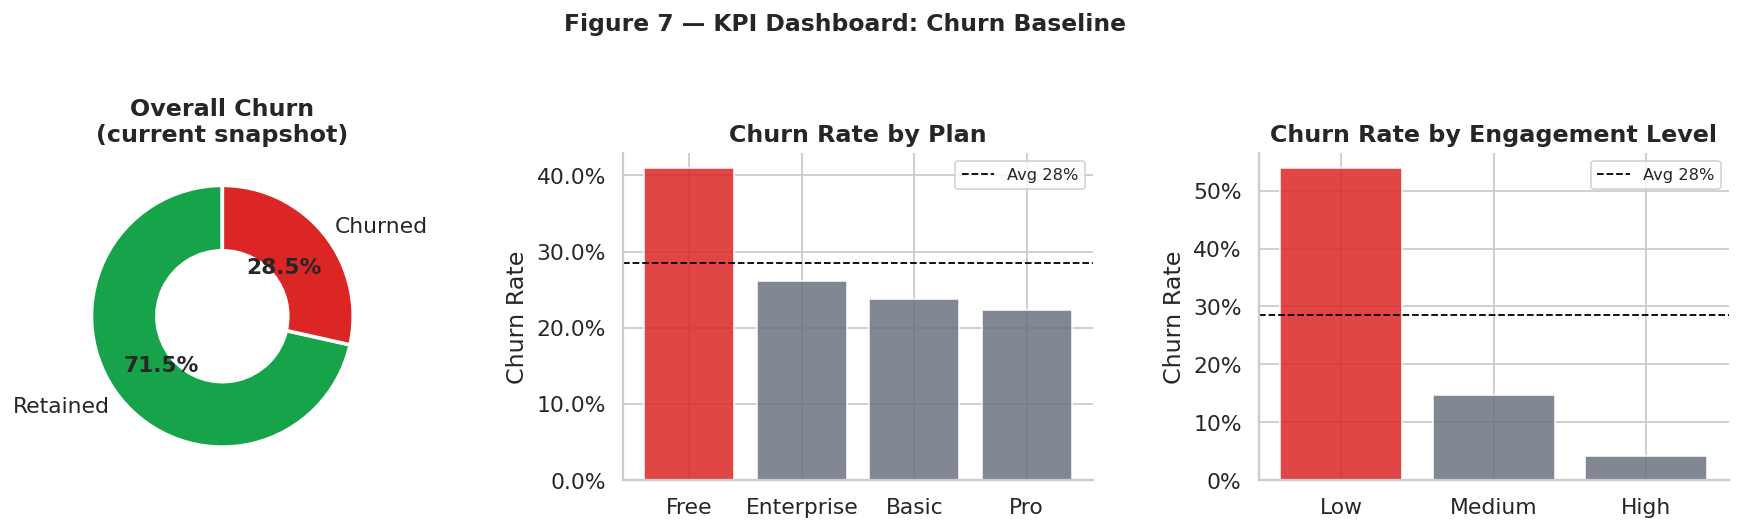

In [33]:
# ── Dashboard-style KPI visual ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Donut — overall churn
ax = axes[0]
sizes = [retained_users, churned_users]
colors_d = [BRAND_COLORS['success'], BRAND_COLORS['danger']]
wedges, texts, autotexts = ax.pie(sizes, labels=['Retained', 'Churned'],
                                   colors=colors_d, autopct='%1.1f%%',
                                   startangle=90,
                                   wedgeprops={'width': 0.5, 'edgecolor': 'white', 'linewidth': 2})
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax.set_title('Overall Churn\n(current snapshot)', fontweight='bold')

# 2. Bar — churn rate by plan
ax = axes[1]
colors_plan = [BRAND_COLORS['danger'] if r > 0.30 else BRAND_COLORS['neutral']
               for r in plan_cr.values]
bars = ax.bar(plan_cr.index, plan_cr.values, color=colors_plan, alpha=0.85)
ax.set_ylabel('Churn Rate')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Churn Rate by Plan', fontweight='bold')
ax.axhline(overall_churn_rate, color='black', linestyle='--', linewidth=1,
           label=f'Avg {overall_churn_rate:.0%}')
ax.legend(fontsize=9)

# 3. Bar — churn rate by engagement
ax = axes[2]
eng_order = ['Low', 'Medium', 'High']
eng_vals = [eng_cr.get(e, 0) for e in eng_order]
colors_eng = [BRAND_COLORS['danger'] if v > 0.30 else BRAND_COLORS['neutral']
              for v in eng_vals]
ax.bar(eng_order, eng_vals, color=colors_eng, alpha=0.85)
ax.set_ylabel('Churn Rate')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Churn Rate by Engagement Level', fontweight='bold')
ax.axhline(overall_churn_rate, color='black', linestyle='--', linewidth=1,
           label=f'Avg {overall_churn_rate:.0%}')
ax.legend(fontsize=9)

plt.suptitle('Figure 7 — KPI Dashboard: Churn Baseline', fontweight='bold', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('fig7_kpi_dashboard.png', bbox_inches='tight')
plt.show()


---
## 5. Final Summary & Recommendations

### 5.1 Key Findings

1. **Overall churn rate is ~28.5%** — significant for a subscription business where CAC is rising.

2. **Free plan shows the highest churn:** Users on the Free plan churn at the highest rate, likely because they have the lowest switching cost and minimal investment in the product.

3. **Low engagement = high churn:** Users in the lowest engagement tertile (fewest app events) churn at dramatically higher rates. A large share of churned users recorded **zero app events**, suggesting they disengaged before formally leaving.

4. **Support contact is a churn signal:** Churned users opened more tickets on average, particularly around **billing** topics. High resolution times correlate with frustration and eventual churn.

5. **Enterprise & Pro plans retain better:** Higher-value subscribers (Pro, Enterprise) churn less — but losses in these tiers are costlier in terms of revenue impact.

---

### 5.2 Recommendations

| Priority | Recommendation | Rationale |
|---|---|---|
| 🔴 High | **Implement a 30-day inactivity alert & re-engagement campaign** | Zero-event users are the strongest churn predictor; early intervention is cheaper than win-back |
| 🔴 High | **Reduce billing friction** (clearer invoices, proactive renewal reminders) | Billing is the top support topic among churned users |
| 🟡 Medium | **Introduce an onboarding flow for new Free users** with a path to upgrade | Free plan has highest churn; a structured upgrade nudge at day 7/30 could convert or retain |
| 🟡 Medium | **Set resolution time SLA < 4 hours for paying plans** | Long resolution times precede churn; a tiered SLA would protect high-value subscribers |
| 🟢 Low | **Conduct cohort analysis as time-series data becomes available** | Snapshot data limits causal inference; monthly MCR tracking will enable trend detection |

---

### 5.3 KPI to Monitor Going Forward

> **Monthly Churn Rate (MCR) = churned subscribers ÷ active subscribers at start of month**  
> **Current baseline estimate: ~28.5% cumulative (snapshot)**  
> **Target: Reduce to <20% within 2 quarters via the interventions above**

Track MCR broken down by **plan tier** and **engagement cohort** every month.  
Pair with **% users with 0 events in last 30 days** as an early-warning leading indicator.


In [35]:
print("=" * 60)
print("  ANALYSIS COMPLETE")
print("=" * 60)
print(f"  Total users analysed         : {total_users}")
print(f"  Baseline churn rate          : {overall_churn_rate:.1%}")
print(f"  Highest churn plan           : {plan_cr.index[0]} ({plan_cr.iloc[0]:.1%})")
print(f"  % churned with zero activity : {(df[df['churned']]['total_events'] == 0).mean():.1%}")
print(f"  Avg billing tickets (churned): {df[df['churned']]['n_billing'].mean():.2f}")
print(f"  Avg resolution time          : {sup['resolution_time_hours'].mean():.1f} hours")

  ANALYSIS COMPLETE
  Total users analysed         : 400
  Baseline churn rate          : 28.5%
  Highest churn plan           : Free (41.0%)
  % churned with zero activity : 72.8%
  Avg billing tickets (churned): 0.76
  Avg resolution time          : 10.4 hours
